In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "Machine learning is fun",
    "Machine learning is powerful",
    "AI is the future"
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(documents)

print("Feature Names:", vectorizer.get_feature_names_out())
print("TF-IDF Matrix:\n", X.toarray())

Feature Names: ['ai' 'fun' 'future' 'is' 'learning' 'machine' 'powerful' 'the']
TF-IDF Matrix:
 [[0.         0.63174505 0.         0.37311881 0.4804584  0.4804584
  0.         0.        ]
 [0.         0.         0.         0.37311881 0.4804584  0.4804584
  0.63174505 0.        ]
 [0.54645401 0.         0.54645401 0.32274454 0.         0.
  0.         0.54645401]]


In [2]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2

data = load_iris()
X = data.data
y = data.target

selector = SelectKBest(score_func=chi2, k=2)
X_new = selector.fit_transform(X, y)

print("Original shape:", X.shape)
print("Reduced shape:", X_new.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = np.array([[10], [20], [30], [40]])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Normalized Data:\n", scaled_data)

Normalized Data:
 [[0.        ]
 [0.33333333]
 [0.66666667]
 [1.        ]]


In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

data = np.array([[10], [20], [30], [40]])

scaler = StandardScaler()
transformed_data = scaler.fit_transform(data)

print("Transformed Data:\n", transformed_data)

Transformed Data:
 [[-1.34164079]
 [-0.4472136 ]
 [ 0.4472136 ]
 [ 1.34164079]]


In [ ]:
# Each feature: subtract mean, divide by std deviation from sklearn.preprocessing import StandardScaler import numpy as np scaler = StandardScaler() X_scaled = scaler.fit_transform(X) # Manual formula: # X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

In [1]:
from sklearn.preprocessing import StandardScaler

In [2]:
import numpy as np

In [3]:
from sklearn.datasets import load_iris 
import matplotlib.pyplot as plt

In [4]:
# 1. Load data (150 samples, 4 features)
data = load_iris()

In [5]:
X, y = data.data, data.target

In [6]:
 # 2. Standardize
X_std = (X - X.mean(axis=0)) / X.std(axis=0) 

In [8]:
# 3. Covariance matrix
cov = np.cov(X_std.T)

In [9]:
# 4. Eigen decomposition
vals, vecs = np.linalg.eig(cov) 
idx = np.argsort(vals)[::-1] 
vals, vecs = vals[idx], vecs[:, idx]

In [10]:
# 5. Project to 2D 
X_pca = X_std @ vecs[:, :2]

In [11]:
# 6. Visualize
colors = ['#7F77DD', '#1D9E75', '#D85A30'] 
for i, label in enumerate(data.target_names): 
    mask = y == i

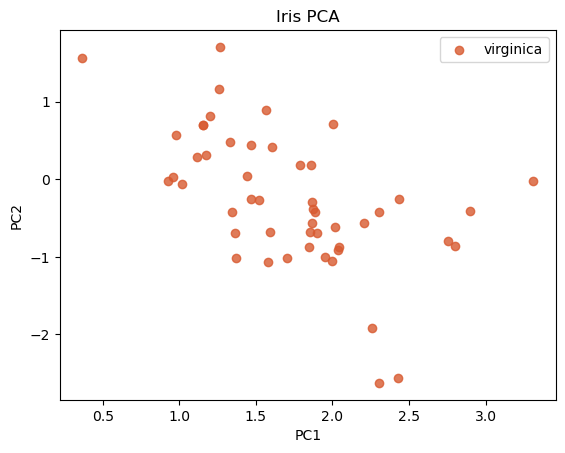

[0.72962445 0.22850762]


In [13]:
plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=label, alpha=0.8)
plt.xlabel('PC1'); plt.ylabel('PC2') 
plt.legend(); 
plt.title('Iris PCA'); 
plt.show() # --- OR use sklearn shortcut --- 
from sklearn.decomposition import PCA 
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_std) 
print(pca.explained_variance_ratio_)

## PCA with formula

#### Step-1 :create Dataset

In [47]:
import numpy as np
import pandas as pd

data = {
    'X': [2, 4, 6, 8, 10],
    'Y': [1, 3, 5, 7, 9]
}

df = pd.DataFrame(data)
print(df)

    X  Y
0   2  1
1   4  3
2   6  5
3   8  7
4  10  9


#### Step-2: Scale the Data
- PCA is very sensitive, so scaling is compulsory (Mean =0 and Standard Deviation =1)

In [48]:
from sklearn.preprocessing import StandardScaler
# for PCA scaling is most important
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print(scaled_data)

[[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]


#### Step-3: Calculate Covariance Matrix

In [49]:
cov_matrix = np.cov(scaled_data.T)
print(cov_matrix)

[[1.25 1.25]
 [1.25 1.25]]


#### Step-4 : find Eigen Value

In [50]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [ 2.50000000e+00 -2.22044605e-16]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


#### Step - 5 : Sort the Eigen Values

In [51]:
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

print(sorted_eigenvalues)
print(sorted_eigenvectors)

[ 2.50000000e+00 -2.22044605e-16]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [52]:
n_components = 1
eigenvector_subset = sorted_eigenvectors[:, 0:n_components]

reduced_data = np.dot(scaled_data, eigenvector_subset)

print(reduced_data)

[[-2.]
 [-1.]
 [ 0.]
 [ 1.]
 [ 2.]]


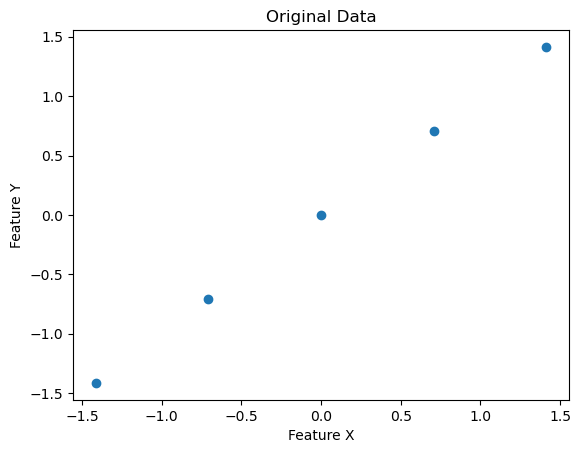

In [53]:
import matplotlib.pyplot as plt

plt.scatter(scaled_data[:, 0], scaled_data[:, 1])
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.title("Original Data")

plt.show()

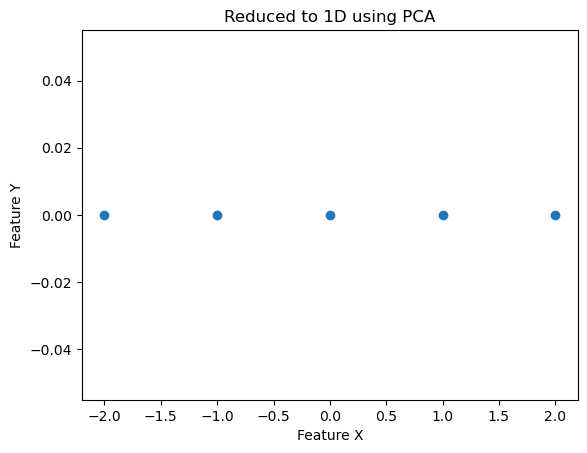

In [54]:
plt.scatter(reduced_data, np.zeros_like(reduced_data))#np.zeros_like()to make two dimension
plt.title("Reduced to 1D using PCA")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.show()

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

print(pca_data)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

[[-2.]
 [-1.]
 [ 0.]
 [ 1.]
 [ 2.]]
Explained Variance Ratio: [1.]


In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)
print(X_pca)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

[[-2.00000000e+00  1.48952049e-16]
 [-1.00000000e+00 -4.96506831e-17]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  4.96506831e-17]
 [ 2.00000000e+00  9.93013661e-17]]
Explained Variance Ratio: [1.00000000e+00 3.69778549e-33]


## Implement PCA on iris Dataset

In [57]:
#import necessary libraries
from sklearn.datasets import load_iris
import pandas as pd



In [58]:
#load dataset
iris = load_iris()

X = iris.data   # features
y = iris.target # labels



In [59]:
#create a Dataframe
df = pd.DataFrame(X, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [60]:
#Apply scaling on Dataset
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
#implement PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [62]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


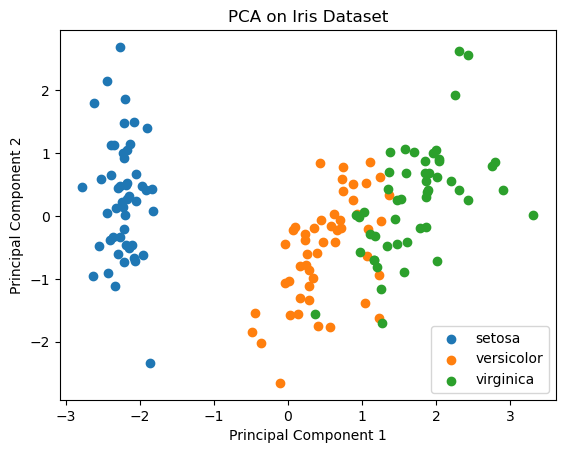

In [63]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(3):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=iris.target_names[i])#select First PC and Second PC

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.legend()

plt.show()

In [64]:
print("Principal Components:\n", pca.components_)

Principal Components:
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


In [65]:
#split the dataset for training and testing
from sklearn.model_selection import train_test_split

In [66]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [67]:
# Apply logistic regression algorithm
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

In [68]:
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [69]:
model.score(x_test,y_test)

1.0

In [70]:
#find no of PC
pca.n_components_

4

In [71]:
x_train_pca,x_test_pca,y_train,y_test=train_test_split(X_pca,y,test_size=0.2)

In [72]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train_pca,y_train)

LogisticRegression(max_iter=1000)

In [73]:
model1.score(x_test_pca,y_test)

1.0

In [74]:
# Let's select no of PCA
pca=PCA(n_components=2)

In [75]:
x_pca=pca.fit_transform(X)

In [76]:
x_train_pca,x_test_pca,y_train,y_test=train_test_split(x_pca,y,test_size=0.2)

In [77]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train_pca,y_train)

LogisticRegression(max_iter=1000)

In [79]:
model1.score(x_test_pca,y_test)

0.8333333333333334